# M3 — Brief 2 : ce que ce jeu de données permet, et ce qu'il faut fabriquer pour la suite

Le brief 1 a conclu sur la **qualité** des données : `utilisable sous conditions`.
Ce notebook porte sur leur **capacité** — un jeu irréprochable peut être incapable
de porter la question qu'on veut lui poser.

**Convention de ce notebook.** Le calcul lourd vit dans les scripts `run_*_b2.py`
et les modules `src/brief2/`, pas ici : c'est ce qui rend le travail rejouable à
graine fixe hors de tout noyau Jupyter. Le notebook charge leurs sorties, les
met en regard, rejoue en direct les mécanismes qui se démontrent mieux qu'ils ne
se racontent — traitement des catégories, mécanisme de Laplace — et conclut.

Pour tout rejouer depuis zéro :

```bash
python run_capacite_b2.py && python run_augmentation_b2.py && python run_generation_b2.py
python run_detection_b2.py && python run_verdicts_b2.py && python run_confidentialite_b2.py
python run_transmission_b2.py
```

**Graine unique** : `SEED = 25082026`. La graine du lot de contrôle amont
(`20260825`) n'est volontairement pas réutilisée, pour qu'aucune reproduction ne
soit ambiguë.

## 0. Point de départ et intégrité

In [1]:
import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Le notebook vit dans notebooks/ ; les modules et les sorties sont à la racine
# de work/M3. On s'y place une fois pour toutes.
RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(RACINE)
sys.path.insert(0, str(RACINE))

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

OUT = RACINE / "output"


def charger(chemin):
    return json.loads((OUT / chemin).read_text(encoding="utf-8"))


from src.brief2.seed import SEED
from src.brief2.sources import prepared_checksums

print("racine :", RACINE)
print("graine :", SEED)

racine : C:\devs\formation-Simplon\projets\diagops-m3\work\M3
graine : 25082026


**Arbitrage A1** — le brief 2 part de **notre préparation du brief 1**
(`output/processed/`), et non de la référence commune `m2_for_m3`. Cette
préparation en dérive, la filiation reste traçable, et le rapprochement temporel
du brief 1 devient exploitable comme instrument de détection à l'étape 4.

Les empreintes ci-dessous rattachent tout ce qui suit à un état précis des
fichiers.

In [2]:
empreintes = pd.Series(prepared_checksums()).str.slice(0, 16) + "…"
display(empreintes.to_frame("SHA-256 (tronqué)"))

capacite = charger("capacite/capacite.json")
depart = capacite["point_de_depart"]
print(
    f"parc {depart['parc']} · événements {depart['evenements']} · "
    f"interventions {depart['interventions']} · mesures {depart['mesures']}"
)

,SHA-256 (tronqué)
equipment,325d2f3fc4a76c56…
events,7d3156f0af6d13ee…
maintenance,2a852490aa4914d1…
sensors,87b51cd2177f57bb…


parc 416 · événements 514 · interventions 1788 · mesures 50277


## 1. Ce que le jeu de données ne permet pas

Première règle de l'étape : **chiffrer l'incapacité avant toute fabrication**.
Une fois des lignes générées, la mesure du manque n'est plus possible.

In [3]:
desequilibres = pd.DataFrame(capacite["desequilibres"])
display(
    desequilibres[
        ["variable", "modalites", "plus_representee", "effectif_max",
         "moins_representee", "effectif_min", "ratio"]
    ]
)

,variable,modalites,plus_representee,effectif_max,moins_representee,effectif_min,ratio
0,equipment_type,18,pump,57,steam_unit,5,11.40
1,site_id,4,SITE-NORD,173,SITE-OUEST,16,10.81
2,event_type,4,incident,232,alert,49,4.73
3,criticality,4,medium,173,critical,46,3.76
4,severity,4,high,213,low,71,3.00


Le rapport demandé par le brief est un **rapport d'effectifs**, distinct du
rapport de *taux* de couverture (×23 entre `critical` et `low`) établi au brief 1.
Les deux disent des choses différentes : le premier décrit le parc, le second
décrit ce qu'on a choisi d'observer.

In [4]:
couverture_evt = capacite["couverture_evenements"]
print(
    f"événements documentés : {couverture_evt['evenements_documentes']} "
    f"/ {couverture_evt['evenements_total']}"
)
display(pd.DataFrame(couverture_evt["par_categorie"]))
display(pd.DataFrame(couverture_evt["test_independance"])[
    ["variable", "khi2", "p_value", "significatif_5pct"]
])

événements documentés : 89 / 514


,variable,modalite,evenements,documentes,part_documentee_pct
0,event_type,alert,49,5,10.20
1,event_type,observation,116,18,15.52
2,event_type,intervention,117,20,17.09
3,event_type,incident,232,46,19.83
4,severity,critical,73,9,12.33
5,severity,high,213,35,16.43
6,severity,medium,157,30,19.11
7,severity,low,71,15,21.13


,variable,khi2,p_value,significatif_5pct
0,event_type,3.0194,0.3886,False
1,severity,2.4569,0.4831,False


La documentation des événements décroît quand la gravité augmente — 12,3 % pour
`critical` contre 21,1 % pour `low`. Le test du khi² ne rejette pas
l'indépendance : l'écart n'est pas distinguable du hasard sur ces effectifs. Il
est cité comme **tendance mesurée, pas comme fait établi** — et c'est le brief 1
qui porte le fait dur, lui non statistique : 6 des 8 mesures de vibration au-delà
de 5 mm/s ne sont appariées à aucun événement, dont le pic à 9,76.

In [5]:
segmentation = capacite["segmentation"]
print("état 1 — parc entier :", segmentation["etat_1_parc_entier"]["conclusion"])
print()
etat2 = segmentation["etat_2_strate_puis_segments"]
print(
    f"état 2 — strate {etat2['strate_declaree']} ({etat2['equipements_strate']} équipements) "
    f"puis k = {etat2['k_retenu']} sur {etat2['equipements_segmentes']}, "
    f"silhouette {etat2['silhouette_retenue']}"
)
display(pd.DataFrame(segmentation["profil"]))
display(pd.DataFrame(segmentation["croisement_couverture"]))

état 1 — parc entier : partition rejetée — le groupe majoritairement isolé est défini par des compteurs d'activité tous nuls, la silhouette récompense une séparation triviale et le parc actif reste non structuré

état 2 — strate SEG-INACTIF (50 équipements) puis k = 2 sur 366, silhouette 0.1929


,segment,equipements,criticite_ordinale,puissance_kw,age_annees,part_correctives,n_evenements,n_evenements_graves,n_interventions,indisponibilite_min,cout_pieces_eur,type_dominant,site_dominant,criticite_dominante,types_distincts
0,SEG-1,192,1.36,73.41,11.36,0.19,1.64,1.10,6.66,1134.80,1601.19,pump (19 %),SITE-NORD (44 %),medium (42 %),18
1,SEG-2,174,1.33,71.65,11.35,0.20,1.09,0.41,2.93,346.45,452.80,conveyor (11 %),SITE-NORD (41 %),medium (41 %),18
2,SEG-INACTIF,50,1.24,72.78,10.69,0.00,0.18,0.08,0.00,0.00,0.00,chiller (12 %),SITE-NORD (34 %),medium (44 %),16


,segment,equipements,instrumentes,taux_pct
0,SEG-2,174,2,1.15
1,SEG-INACTIF,50,1,2.00
2,SEG-1,192,33,17.19


**Arbitrage A3** — la segmentation retient référentiel **et** activité, et
**exclut la couverture instrumentale des variables**. L'inclure aurait rendu la
conclusion tautologique : « ces groupes sont mal couverts » n'apprend rien si la
couverture a servi à les construire. Elle est croisée **après**, et c'est ce
croisement qui constitue le résultat : `SEG-2` réunit 174 équipements et 2
capteurs — 1,15 %.

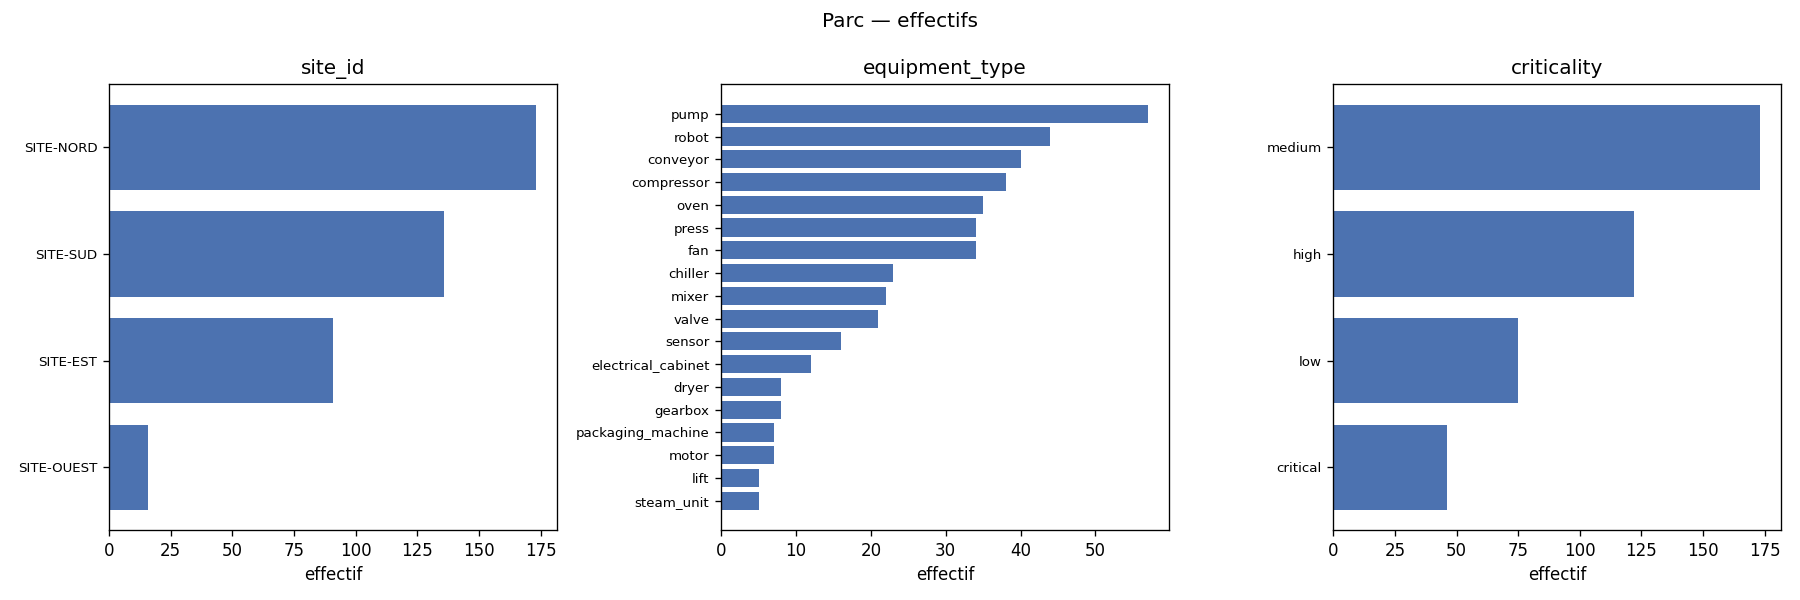

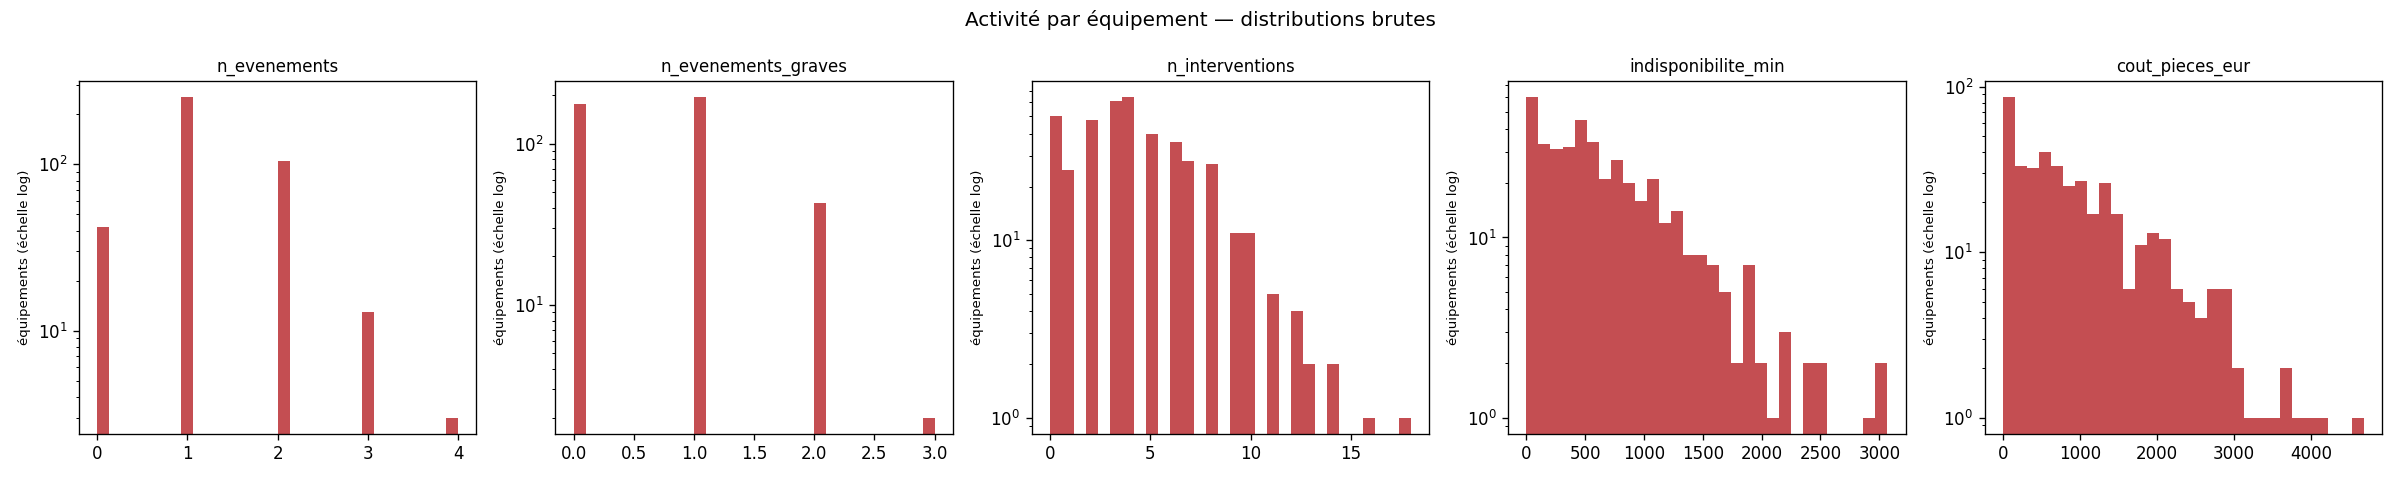

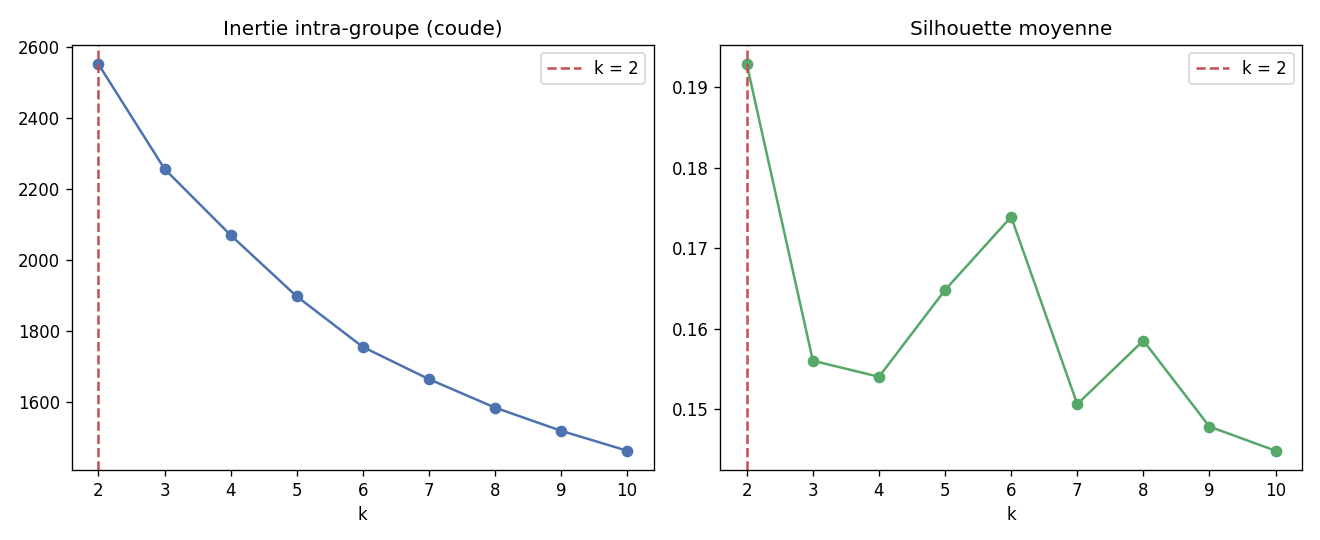

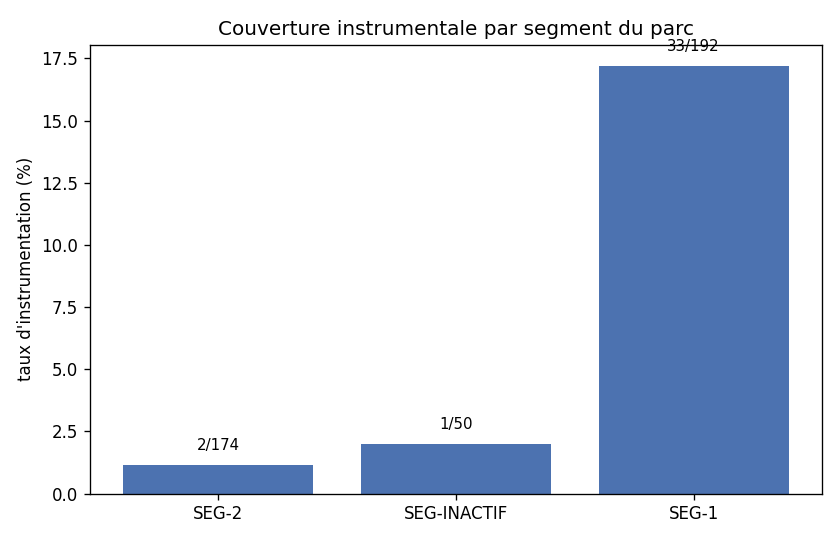

In [6]:
for figure in ("effectifs_parc.png", "distributions_activite.png",
               "choix_k.png", "segments_couverture.png"):
    display(Image(filename=str(OUT / "capacite" / "figures" / figure)))

### Trois questions que ce jeu ne permet pas de traiter

| Question | Chiffre qui l'interdit |
|---|---|
| « Quels équipements de `SITE-OUEST` vont tomber en panne ? » | **0 capteur sur 16 équipements** — aucune mesure, aucune série, rien à apprendre |
| « Une presse ou une vanne montre-t-elle une signature avant défaillance ? » | **7 types sans aucune mesure**, dont `press` (34) et `valve` (21) — 90 équipements, 21,6 % du parc |
| « Quelle est la signature capteur d'un incident grave ? » | **9 événements `critical` documentés sur 73**, et le pic de vibration le plus élevé du corpus n'est apparié à aucun événement |

Le détail est dans `docs/capacite_jeu_donnees.md`.

## 2. Augmenter — ce que chaque technique préserve et détruit

Cinq procédés appliqués à une série réelle. La colonne qui compte n'est pas ce
qu'ils préservent : c'est ce qu'ils **détruisent**.

,procedure_id,nom,famille,parametres,intention,attendu_preserve,attendu_detruit,mesure_preserve,mesure_detruit,collisions_cle_logique
0,PROC-AUG-BRUIT,Bruit gaussien additif,valeur,"{""sigma_ratio_ecart_type"": 0.02}",produire des variantes proches sans changer le...,ordre de grandeur ; régularité du pas ; lien a...,valeurs exactes ; un peu d'autocorrélation,ordre_de_grandeur ; fidelite_point_a_point ; s...,NaN,50225
1,PROC-AUG-ECHELLE,Mise à l'échelle multiplicative,valeur,"{""facteur"": 1.05}",simuler un défaut d'étalonnage,forme ; autocorrélation ; régularité du pas,niveau absolu ; plausibilité si dépassement de...,fidelite_point_a_point ; structure_temporelle ...,ordre_de_grandeur ; signal_aux_evenements,50225
2,PROC-AUG-DECALAGE,Décalage temporel global,temps,"{""pas_nominaux"": 3, ""heures"": 18}",produire une variante décorrélée du calendrier...,toutes les marginales ; autocorrélation ; régu...,lien aux événements ; appartenance à la périod...,ordre_de_grandeur ; structure_temporelle ; reg...,NaN,49949
3,PROC-AUG-PERMUT,Permutation de segments,structure,"{""taille_bloc"": 4, ""duree_bloc_h"": 24}",conserver la population de valeurs en cassant ...,marginales exactes ; régularité du pas ; plaus...,structure temporelle ; lien aux événements,ordre_de_grandeur ; regularite_du_pas ; plausi...,fidelite_point_a_point,50225
4,PROC-AUG-DEFORM,Déformation de l'axe temporel,temps,"{""amplitude"": 0.25}",produire une variante au rythme irrégulier,toutes les marginales ; forme de la série,grille d'échantillonnage ; lien aux événements,ordre_de_grandeur ; structure_temporelle ; pla...,regularite_du_pas,73


,procedure_id,delta_moyenne_pct,delta_ecart_type_pct,correlation_point_a_point,autocorr_lag1_avant,autocorr_lag2_avant,autocorr_lag4_avant,autocorr_lag1_apres,autocorr_lag2_apres,autocorr_lag4_apres,part_pas_nominal_apres_pct,lignes,hors_plage_robuste_avant,hors_plage_robuste_apres,en_fenetre_evenement_avant,en_fenetre_evenement_apres,collisions_cle_logique,series,ordre_de_grandeur_pct,fidelite_point_a_point_pct,structure_temporelle_pct,regularite_du_pas_pct,plausibilite_physique_pct,lien_aux_evenements_pct,signal_aux_evenements_pct,cle_logique_libre_pct
0,PROC-AUG-BRUIT,-0.0003,0.0335,0.9998,0.0791,-0.5846,0.6942,0.0790,-0.5845,0.6940,99.873,50225,8,8,2560,2560,50225,70,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0
1,PROC-AUG-DECALAGE,0.0000,0.0000,NaN,0.0791,-0.5846,0.6942,0.0791,-0.5846,0.6942,99.873,50225,8,8,2560,2553,49949,70,100.0,NaN,100.0,100.0,100.0,97.1,90.0,0.0
2,PROC-AUG-DEFORM,0.0000,0.0000,NaN,0.0791,-0.5846,0.6942,0.0791,-0.5846,0.6942,0.014,50225,8,8,2560,2577,73,70,100.0,NaN,100.0,0.0,100.0,97.1,88.6,0.0
3,PROC-AUG-ECHELLE,5.0002,4.9962,1.0000,0.0791,-0.5846,0.6942,0.0791,-0.5846,0.6942,99.873,50225,8,13,2560,2560,50225,70,0.0,100.0,100.0,100.0,94.3,100.0,0.0,0.0
4,PROC-AUG-PERMUT,0.0000,0.0000,0.3466,0.0791,-0.5846,0.6942,0.0631,-0.5078,0.4415,99.873,50225,8,8,2560,2560,50225,70,100.0,0.0,27.1,100.0,100.0,100.0,31.4,0.0


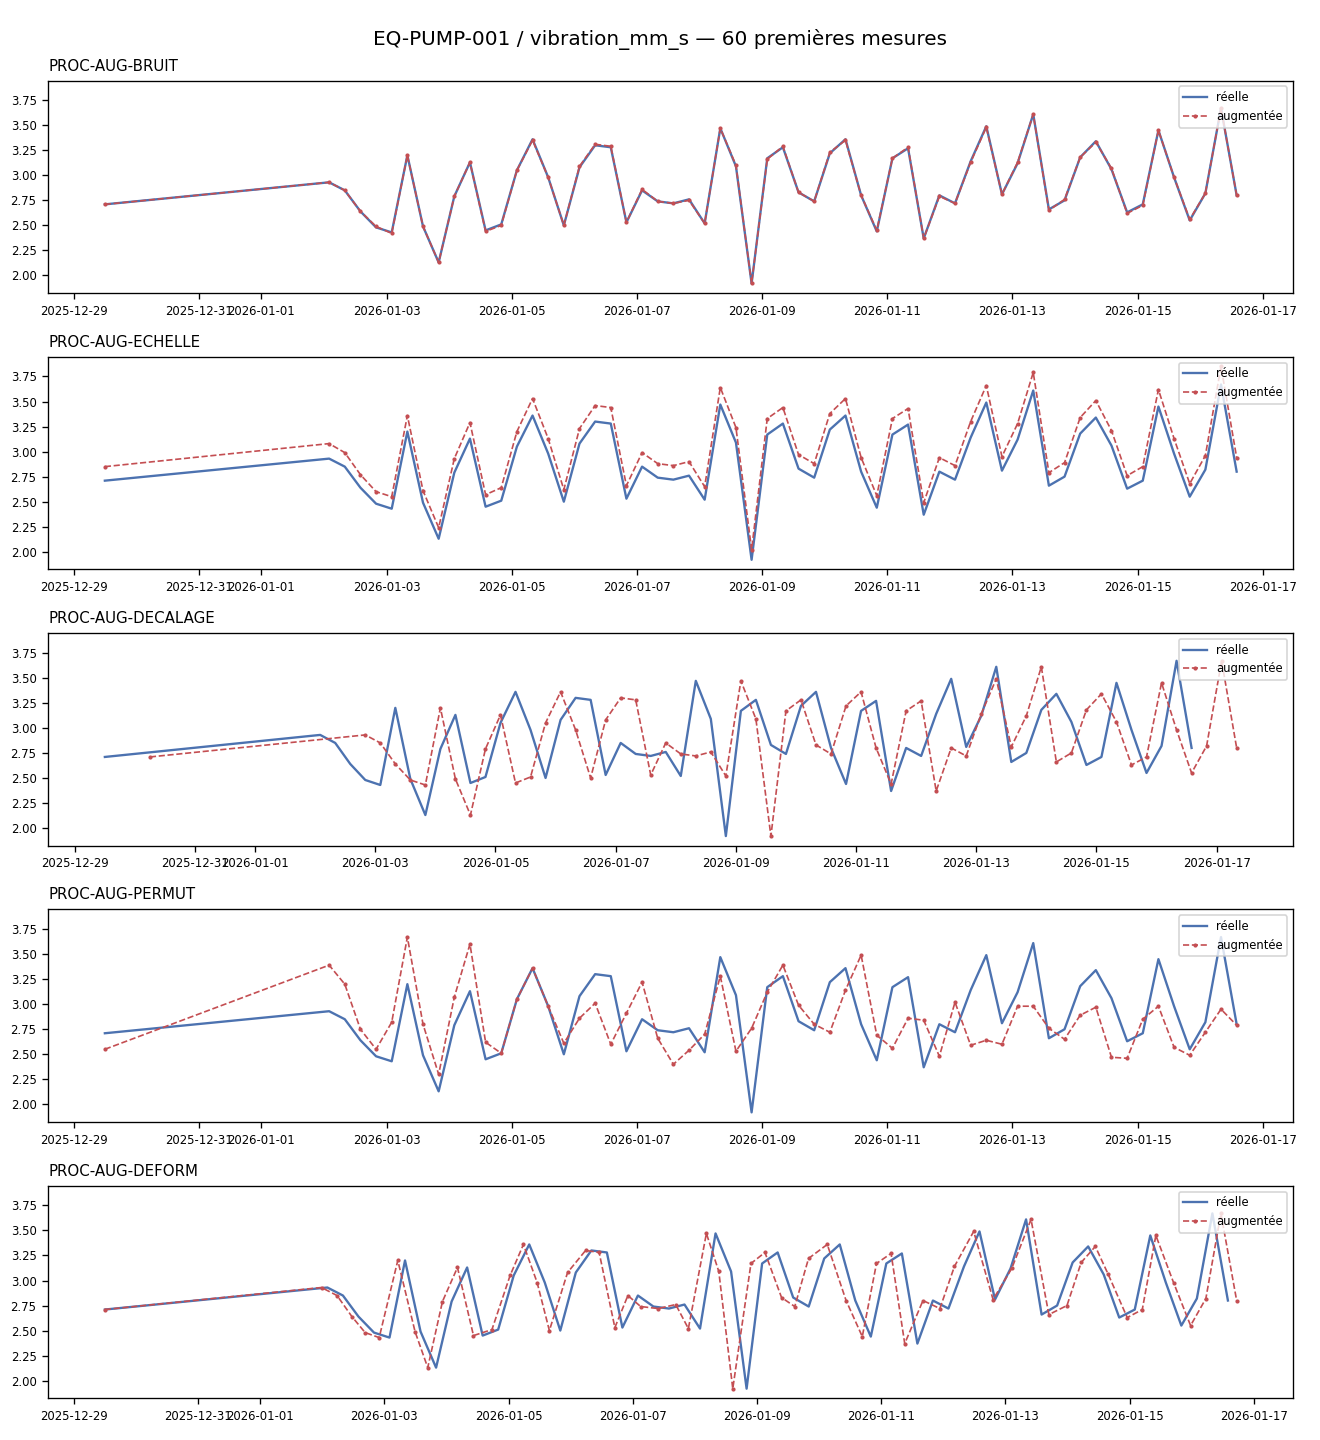

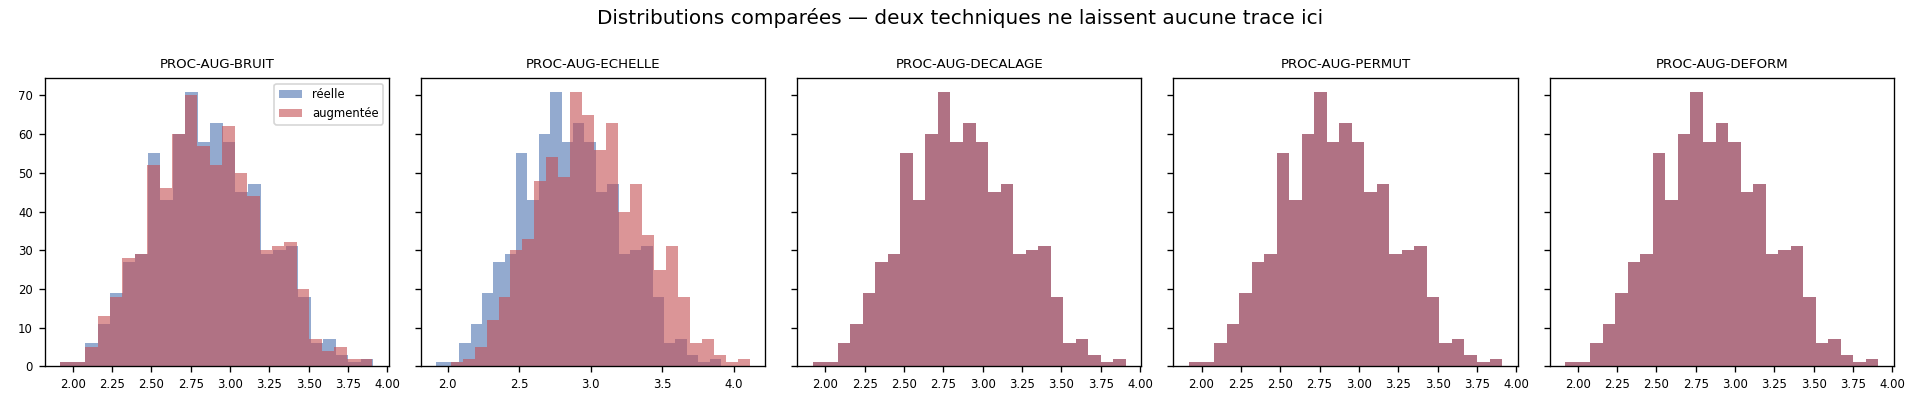

In [7]:
fiche = pd.read_csv(OUT / "augmentation" / "fiche_techniques.csv")
display(fiche)
display(pd.read_csv(OUT / "augmentation" / "mesures_par_technique.csv"))
display(Image(filename=str(OUT / "augmentation" / "figures" / "augmentation_series.png")))
display(Image(filename=str(OUT / "augmentation" / "figures" / "augmentation_distributions.png")))

Le cas à retenir est `PROC-AUG-PERMUT` : la permutation détruit **intégralement**
la structure temporelle et rend des marginales identiques au réel. Sur un
histogramme, elle est indiscernable d'une série intacte. Une technique qui produit
une série physiquement impossible se documente, elle ne se supprime pas.

## 3. Générer — deux voies, et ce que chacune perd

**Arbitrage A2** — périmètre généré : `SITE-OUEST ∩ SEG-2`, 8 équipements,
2 capteurs, janvier 2026. Il satisfait la consigne (`SITE-OUEST`) et vise le trou
chiffré à l'étape 1 (`SEG-2`, 1,15 % de couverture), avec une répartition de
criticité équilibrée — 2 `critical`, 2 `high`, 2 `medium`, 2 `low`.

In [8]:
generation = charger("generation/generation.json")
print("périmètre :", generation["perimetre"]["arbitrage"])
print("équipements :", ", ".join(generation["perimetre"]["equipements"]))
print("volumes :", generation["volumes"])
print("voisinage :", {k: v for k, v in generation["voisinage"].items() if k != "journal_interpolation"})
print("journal :", generation["voisinage"]["journal_interpolation"])

périmètre : A2 — SITE-OUEST ∩ SEG-2
équipements : EQ-COMP-189, EQ-DRYER-264, EQ-FAN-104, EQ-FAN-120, EQ-OVEN-203, EQ-PUMP-002, EQ-PUMP-230, EQ-ROBOT-173
volumes : {'PROC-GEN-MARG-V1': 1984, 'PROC-GEN-SMOTE-V1': 1799}
voisinage : {'k': 5, 'penalite_type_different': 1.0, 'descripteurs': ['criticite_ordinale', 'puissance_log', 'age_annees'], 'donneurs_disponibles': 30, 'voisins_retenus': {'EQ-COMP-189': ['EQ-COMP-113', 'EQ-OVEN-386', 'EQ-FAN-204', 'EQ-OVEN-123', 'EQ-CHILL-188'], 'EQ-DRYER-264': ['EQ-CHILL-168', 'EQ-FAN-304', 'EQ-MIX-159', 'EQ-FAN-002', 'EQ-SENSOR-305'], 'EQ-FAN-104': ['EQ-CHILL-001', 'EQ-FAN-284', 'EQ-SENSOR-305', 'EQ-FAN-304', 'EQ-FAN-002'], 'EQ-FAN-120': ['EQ-FAN-304', 'EQ-COMP-002', 'EQ-FAN-003', 'EQ-MIX-159', 'EQ-FAN-002'], 'EQ-OVEN-203': ['EQ-OVEN-223', 'EQ-COMP-233', 'EQ-OVEN-001', 'EQ-COMP-002', 'EQ-SENSOR-305'], 'EQ-PUMP-002': ['EQ-PUMP-006', 'EQ-PUMP-171', 'EQ-MIX-379', 'EQ-PUMP-001', 'EQ-FAN-003'], 'EQ-PUMP-230': ['EQ-CHILL-001', 'EQ-SENSOR-305', 'EQ-MIX-259', '

### Le traitement des colonnes catégorielles, écrit et non emprunté

Interpoler numériquement une catégorie encodée est le contresens que le critère
bloquant du brief vise. Ici, les colonnes numériques sont interpolées entre
voisins ; les colonnes catégorielles sont tranchées par **vote majoritaire** des
donneurs, jamais moyennées.

In [9]:
import inspect

from src.brief2.generation import vote_majoritaire

print(inspect.getsource(vote_majoritaire))

def vote_majoritaire(valeurs: pd.Series) -> str:
    """Modalité la plus fréquente — traitement des catégories, pas d'interpolation."""
    return str(valeurs.mode().iat[0])



In [10]:
marginales = pd.DataFrame(generation["marginales"])
display(marginales[["origine", "sensor_name", "lignes", "moyenne", "ecart_type", "min", "max"]])

structure = pd.DataFrame(generation["structure_temporelle"])
display(structure)

,origine,sensor_name,lignes,moyenne,ecart_type,min,max
0,réel,temperature_c,2517,57.6031,4.9577,42.34,71.91
1,réel,vibration_mm_s,1558,2.8436,0.3862,1.72,4.47
2,PROC-GEN-MARG-V1,temperature_c,992,57.8714,4.8815,43.62,70.12
3,PROC-GEN-MARG-V1,vibration_mm_s,992,2.8736,0.3874,1.83,4.93
4,PROC-GEN-SMOTE-V1,temperature_c,959,57.9154,3.8469,45.07,70.35
5,PROC-GEN-SMOTE-V1,vibration_mm_s,840,2.8202,0.3284,2.03,4.22


,origine,sensor_name,series,autocorr_lag2_mediane,autocorr_lag4_mediane
0,réel,temperature_c,21,-0.7593,0.8031
1,réel,vibration_mm_s,13,-0.4590,0.5268
2,PROC-GEN-MARG-V1,temperature_c,8,0.0215,-0.0240
3,PROC-GEN-MARG-V1,vibration_mm_s,8,0.0114,-0.0766
4,PROC-GEN-SMOTE-V1,temperature_c,8,-0.5942,0.5986
5,PROC-GEN-SMOTE-V1,vibration_mm_s,7,-0.3102,0.2524


**C'est ici que tout se joue.** Le tirage marginal conserve chaque histogramme —
les moyennes et les écarts-types sont proches du réel — et **détruit
l'autocorrélation de rang 4**, c'est-à-dire le cycle de 24 h : elle passe de 0,80
à −0,02 sur la température. Une comparaison limitée aux marginales conclurait que
la série est fidèle. Elle ne l'est pas : elle a la bonne distribution et aucune
dynamique.

L'interpolation entre voisins, elle, conserve la dynamique (0,60 contre 0,80) et
paie ailleurs : **elle contracte la dispersion**. L'écart-type de la température
tombe à 3,85 contre 4,96 pour le réel, soit un ratio de 0,78. C'est le défaut qui
a motivé un second état du générateur.

> Les deux tableaux ci-dessus portent sur l'**état 1** du générateur
> (`PROC-GEN-SMOTE-V1`), seul existant à l'étape 3. L'état 2
> (`PROC-GEN-SMOTE-V2`, λ élargi à [−0,25 ; 1,25]) est produit à l'étape 4 en
> réponse à ce défaut : ratios σ 0,858 et 0,897 contre 0,783 et 0,810. C'est lui
> qui est transmis.

In [11]:
display(pd.DataFrame(generation["correlation_entre_capteurs"]))
display(pd.DataFrame(generation["reaction_aux_evenements_controle_semestre"]))

,origine,couples,equipements,correlation_mediane
0,réel,359,3,-0.1418
1,PROC-GEN-MARG-V1,992,8,-0.0480
2,PROC-GEN-SMOTE-V1,839,7,-0.0049


,origine,sensor_name,mesures_en_fenetre,mesures_hors_fenetre,moyenne_en_fenetre,moyenne_hors_fenetre,ecart_pct,p_value_mann_whitney,reaction_significative
0,réel — 2026-S1,temperature_c,777,14325,59.1975,57.6480,2.69,0.000000,True
1,réel — 2026-S1,vibration_mm_s,508,8765,3.0490,2.8384,7.42,0.000000,True
2,PROC-GEN-MARG-V1 — 2026-S1,temperature_c,148,5644,57.1179,57.7059,-1.02,0.093434,False
3,PROC-GEN-MARG-V1 — 2026-S1,vibration_mm_s,148,5644,2.8434,2.8598,-0.58,0.829467,False
4,PROC-GEN-SMOTE-V1 — 2026-S1,temperature_c,148,5611,57.4534,58.0369,-1.01,0.092878,False
5,PROC-GEN-SMOTE-V1 — 2026-S1,vibration_mm_s,117,4916,2.8093,2.8070,0.08,0.706953,False


La réaction aux événements est testée **sur le semestre**, pas sur le mois généré.
Motif écrit avant le test : sur janvier seul, le réel lui-même ne montre aucune
réaction détectable (p = 0,18 et p = 0,97) alors qu'elle est franche sur le
semestre. Conclure « les fabriqués ne réagissent pas » à partir d'un test
incapable de voir la réaction du réel n'aurait rien démontré.

In [12]:
controles = pd.DataFrame(generation["controles_metier"])
en_faute = controles[controles["lignes_en_faute"] > 0]
print(f"contrôles métier exécutés : {len(controles)}")
print(f"contrôles avec au moins une ligne en faute : {len(en_faute)}")
display(en_faute if len(en_faute) else controles.head(8))

contrôles métier exécutés : 22
contrôles avec au moins une ligne en faute : 1


,controle,lignes_en_faute,procedure_id
6,R-SEN-009 valeur dans la plage robuste (8 MAD),2,PROC-GEN-MARG-V1


## 4. Se confronter — dans les deux sens

**Sens 1** : nos productions au détecteur de référence, chaque soumission
consignée avec son hypothèse formulée **avant** lancement.
**Sens 2** : nos règles sur le lot de contrôle, verdict par ligne.

In [13]:
tour1 = charger("detection/detection_tour1.json")
tour2 = charger("detection/detection_tour2.json")

soumissions = pd.DataFrame(tour1["soumissions"] + tour2["soumissions"])
print(f"soumissions consignées aux tours 1 et 2 : {len(soumissions)}")
display(soumissions[["soumission", "fichier"]] if "fichier" in soumissions
        else soumissions.iloc[:, :2])
print()
print("générateur, état 2 :", tour2["generateur_v2"])

soumissions consignées aux tours 1 et 2 : 16


,soumission,fichier
0,T1-00,sensor_readings.csv
1,T1-01,temoin_reel.csv
2,T1-02,mesures_PROC-GEN-MARG-V1.csv
3,T1-03,mesures_PROC-GEN-SMOTE-V1.csv
4,T1-04,exemple_PROC-AUG-BRUIT.csv
5,T1-05,exemple_PROC-AUG-ECHELLE.csv
6,T1-06,exemple_PROC-AUG-DECALAGE.csv
7,T1-07,exemple_PROC-AUG-PERMUT.csv
8,T1-08,exemple_PROC-AUG-DEFORM.csv
9,T2-00,exemple_serie_reelle.csv



générateur, état 2 : {'lambda_bornes': [-0.25, 1.25], 'points_extrapoles': 614, 'points_hors_plage': 0, 'lignes': 1799, 'profils': {'reel_janvier': {'temperature_c': {'lignes': 2520, 'ecart_type': 4.9577, 'moyenne': 57.6031, 'autocorrelation_moyenne': {'2': -0.7456, '4': 0.8064}}, 'vibration_mm_s': {'lignes': 1560, 'ecart_type': 0.3864, 'moyenne': 2.8432, 'autocorrelation_moyenne': {'2': -0.4158, '4': 0.5396}}}, 'smote_v1': {'temperature_c': {'lignes': 959, 'ecart_type': 3.8469, 'moyenne': 57.9154, 'autocorrelation_moyenne': {'2': -0.4503, '4': 0.499}}, 'vibration_mm_s': {'lignes': 840, 'ecart_type': 0.3284, 'moyenne': 2.8202, 'autocorrelation_moyenne': {'2': -0.2093, '4': 0.2935}}}, 'smote_v2': {'temperature_c': {'lignes': 959, 'ecart_type': 4.2181, 'moyenne': 57.9138, 'autocorrelation_moyenne': {'2': -0.3831, '4': 0.4055}}, 'vibration_mm_s': {'lignes': 840, 'ecart_type': 0.3634, 'moyenne': 2.8223, 'autocorrelation_moyenne': {'2': -0.1927, '4': 0.2427}}}}}


### Le résultat central du tour 2

`PROC-GEN-SMOTE-V1` et `PROC-GEN-SMOTE-V2` reçoivent **le même verdict — zéro
signalement** — alors que le second est mesurablement meilleur : ratios σ 0,858 et
0,897 contre 0,783 et 0,810.

Le détecteur ne sait pas arbitrer entre deux états du générateur. **Son silence ne
prouve donc rien.** La preuve en est faite au tour 1 : `PROC-GEN-MARG-V1`, série
sans aucune structure temporelle, est déclarée conforme et *plus propre* que les
deux témoins réels. La question « générateur fidèle ou détecteur aveugle ? » se
tranche par un élément extérieur au détecteur — ici l'autocorrélation, qu'il
déclare lui-même hors de son périmètre.

In [14]:
verdicts = charger("detection/verdicts.json")
print("calibrage sur control_sample.csv :",
      f"{verdicts['calibrage']['lignes_justes']} / {verdicts['calibrage']['lignes']} "
      f"({verdicts['calibrage']['part_juste']:.1%})")
print("répartition du lot :", verdicts["lot"]["repartition"])
print("blocs fabriqués sans signature interne :",
      verdicts["lot"]["blocs_fabriques_sans_signature"])
display(pd.DataFrame(verdicts["registre"]))

calibrage sur control_sample.csv : 690 / 720 (95.8%)
répartition du lot : {'réelle': 3810, 'fabriquée': 2160, 'indécidable': 30}
blocs fabriqués sans signature interne : 11


,regle,libelle,portee
0,R-DET-001,bloc intégralement retrouvé dans la livraison ...,réelle
1,R-DET-002,bloc absent de la livraison M3,fabriquée
2,R-DET-003,"correspondance résiduelle, sous le seuil de co...",fabriquée
3,R-DET-004,correspondance partielle intermédiaire — aucun...,indécidable
4,R-DET-010,autocorrélation de rang 4 effondrée : cycle jo...,corroboration
5,R-DET-011,grille d'échantillonnage irrégulière,corroboration
6,R-DET-012,niveau incompatible avec le profil de l'équipe...,corroboration
7,R-DET-013,dispersion incompatible avec le profil de l'éq...,corroboration
8,R-DET-014,valeurs retrouvées chez un autre équipement — ...,corroboration


**Arbitrage A5 — politique d'`indécidable`.** 30 lignes sur 6 000, soit un bloc :
un seuil strict, assumé et mesuré dans les deux sens. Le verdict se prend au bloc
de 30 lignes — unité de fabrication constatée — et une seule famille de règles
décide. Les cinq règles de corroboration n'ont jamais voix au chapitre : portées à
la décision, elles auraient déclaré fabriqués **21 blocs authentiques sur 127**.

C'est le piège que le lot tend : nos 15 règles capteurs du brief 1 détectent la
**qualité**, pas l'**authenticité**, et les lignes réelles du lot portent les
anomalies de la livraison M3.

In [15]:
contre = pd.DataFrame(verdicts["contre_epreuve"])
display(contre)

,controle,lignes_signalees,sur_lignes_reelles,sur_lignes_fabriquees,sur_lignes_indecidables
0,R-SEN-001 clé logique unique,2,2,0,0
1,R-SEN-003 horodatage sur la grille,210,60,150,0
2,R-SEN-005 nom de capteur normalisé,40,40,0,0
3,R-SEN-006 unité conforme,210,210,0,0
4,R-SEN-007 valeur numérique,1,0,0,1
5,R-SEN-008 valeur non sentinelle,1,1,0,0
6,R-SEN-009 valeur dans la plage physique,211,31,180,0
7,R-SEN-013 équipement présent au parc,0,0,0,0
8,R-SEN-014 mesure dans la période,0,0,0,0
9,R-SEN-015 étiquette period cohérente,30,30,0,0


## 5. Protéger une publication agrégée

**Arbitrage A4** — agrégat retenu : le **coût moyen des pièces par site ×
criticité**, choisi sur les effectifs constatés à l'étape 1. Mécanisme de Laplace,
sensibilité bornée par un plafond, budget `ε` balayé sur huit valeurs.

agrégat : coût moyen des pièces par site × criticité
plafond retenu : 750.0 € — comparé à [1128.0, 750.0, 500.0]
budgets testés : [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]


,cellules exploitables / 16,erreur_estimation_mediane,part_cible_retrouvee
epsilon,,,
0.1,0,10589.4,0.0030
0.5,2,2095.3,0.0145
1.0,4,1012.6,0.0290
2.0,8,512.1,0.0770
5.0,11,197.4,0.1475
10.0,12,99.1,0.2950
20.0,15,54.3,0.4665
50.0,15,20.2,0.8120


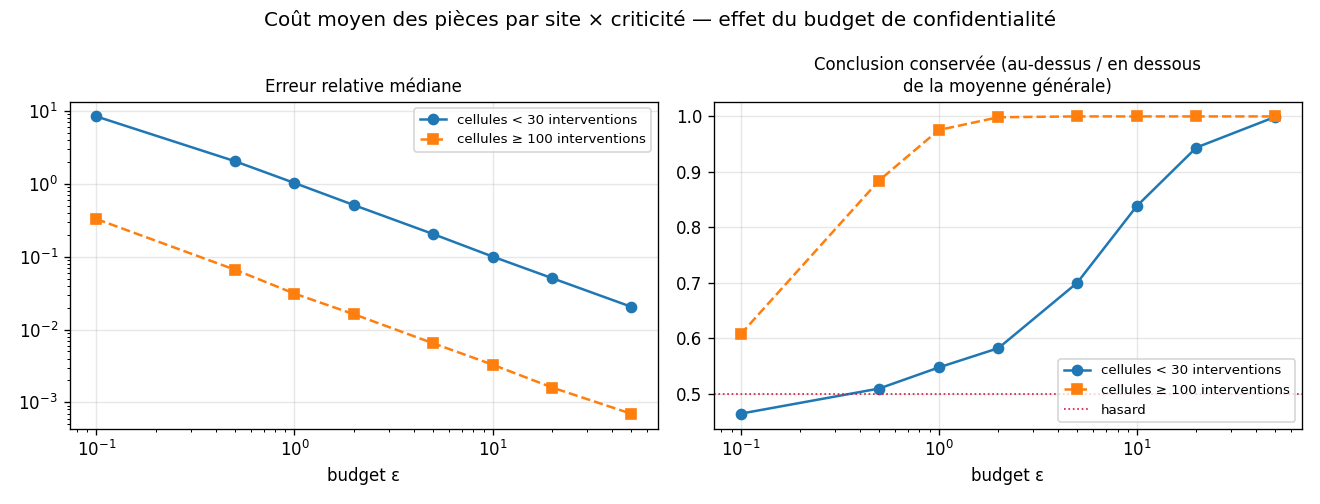

In [16]:
confidentialite = charger("confidentialite/confidentialite.json")
print("agrégat :", confidentialite["agregat"])
print("plafond retenu :", confidentialite["plafond_retenu"], "€ —",
      "comparé à", confidentialite["plafonds_compares"])
print("budgets testés :", confidentialite["epsilons"])

balayage = pd.DataFrame(confidentialite["balayage"])
exploitables = (
    balayage.assign(exploitable=balayage["part_conclusion_conservee"] > 0.90)
    .groupby("epsilon")["exploitable"].sum()
    .rename("cellules exploitables / 16")
)
attaque = pd.DataFrame(confidentialite["attaque"]).set_index("epsilon")
display(pd.concat([exploitables, attaque[["erreur_estimation_mediane", "part_cible_retrouvee"]]], axis=1))
display(Image(filename=str(OUT / "confidentialite" / "figures" / "budgets_epsilon.png")))

### Les deux bornes, et une erreur corrigée en cours d'étape

**La sortie n'est pas le budget, c'est la maille.** À `ε = 5`, la publication par
criticité seule est exploitable sur ses 4 cellules quand la maille croisée en
laisse 5 sur 16 inutilisables. Protéger un agrégat trop peu fourni ne s'achète pas
en budget : on renonce à la finesse.

**L'erreur, et pourquoi elle comptait.** La première version mesurait la
protection par la part des tirages où la moyenne vraie était retrouvée à 10 % près
— et concluait que les grandes cellules étaient les moins protégées, ce qui est
faux. L'indicateur mesurait la **précision** et l'appelait vulnérabilité. Remplacé
par l'attaque par différenciation, conforme au modèle de menace annoncé, qui rend
le résultat théorique attendu : **la protection ne dépend pas de l'effectif**.

## 6. Décider ce qui est transmis à M4

In [17]:
transmission = charger("transmission/transmission.json")
print("décision :", transmission["decision"])
print("volumes :", transmission["volumes"])
print("échéance de réexamen :", transmission["echeance_reexamen"])
print("contrat de provenance respecté :", transmission["contrat"]["conforme"])
print("R-TRA-001, valeurs corrigées :", transmission["R-TRA-001_valeurs_corrigees"])

procedes = pd.DataFrame(transmission["procedes"])
display(procedes[["procedure_id", "famille", "provenance", "transmis", "lignes", "motif_transmission"]])

décision : une partie sous conditions
volumes : {'total': 52076, 'reelles': 50277, 'synthetiques': 1799, 'augmentees': 0, 'part_fabriquee_pct': 3.45}
échéance de réexamen : 2026-12-31
contrat de provenance respecté : True
R-TRA-001, valeurs corrigées : 68


,procedure_id,famille,provenance,transmis,lignes,motif_transmission
0,PROC-GEN-SMOTE-V2,génération,synthétique,True,1799,seul procédé qui conserve une structure tempor...
1,PROC-GEN-SMOTE-V1,génération,synthétique,False,1799,dispersion contractée de 15 à 22 % (ratios σ 0...
2,PROC-GEN-MARG-V1,génération,synthétique,False,1984,détruit toute structure temporelle (autocorrél...
3,PROC-AUG-BRUIT,augmentation,augmentée,False,721,série support hors grille horaire : 721 lignes...
4,PROC-AUG-ECHELLE,augmentation,augmentée,False,721,"biais de niveau de 0,391 σ que le détecteur ne..."
5,PROC-AUG-DECALAGE,augmentation,augmentée,False,721,même support non conforme que PROC-AUG-BRUIT
6,PROC-AUG-DEFORM,augmentation,augmentée,False,721,détruit la régularité du pas ; le comptage du ...
7,PROC-AUG-PERMUT,augmentation,augmentée,False,721,détruit intégralement la structure temporelle ...


In [18]:
couverture = pd.DataFrame(transmission["couverture"])
display(
    couverture[couverture["variable"] != "parc"]
    .pivot_table(index=["variable", "modalite"], columns="etat", values="taux_pct")
)
display(pd.DataFrame(transmission["documentation_par_gravite"]))

etat                  après transmission (réel + fabriqué)  avant transmission (réel seul)
variable  modalite                                                                        
criticité critical                                   34.78                           30.43
          high                                       13.11                           11.48
          low                                         4.00                            1.33
          medium                                      5.20                            4.05
site      SITE-EST                                    5.49                            5.49
          SITE-NORD                                  12.14                           12.14
          SITE-OUEST                                 50.00                            0.00
          SITE-SUD                                    7.35                            7.35

,severity,evenements,documentes,part_pct,etat
0,critical,73,9,12.33,avant
1,high,213,35,16.43,avant
2,medium,157,30,19.11,avant
3,low,71,15,21.13,avant
4,critical,73,10,13.70,après
5,high,213,36,16.90,après
6,medium,157,31,19.75,après
7,low,71,15,21.13,après


**Le piège de l'atténuation par fabrication.** La couverture passe de 8,65 % à
10,58 % et le rapport `critical` / `low` de ×22,9 à ×8,7 **sans qu'un seul
équipement supplémentaire ait été instrumenté**. L'indicateur progresse, le parc
observé est identique. C'est ce constat qui a produit la condition C7 : ne jamais
compter la couverture sans filtrer sur la provenance.

In [19]:
biais = pd.read_csv(OUT / "transmission" / "biais.csv")
for nom, groupe in biais.groupby("biais", sort=False):
    print(f"\n{nom}")
    for _, ligne in groupe.iterrows():
        print(f"   {ligne['indicateur']:<58} {ligne['valeur']}")


B1 — couverture instrumentale
   équipements avec au moins une mesure réelle                36 / 416
   SITE-OUEST, mesures réelles                                0 / 16
   écart de taux critical / low (réel)                        30.43 % contre 1.33 %
   types d'équipement sans aucune mesure réelle               7 / 18
   équipements couverts après transmission (dont fabriqué)    44 / 416 dont 8 fabriqués

B2 — étiquetage des événements
   événements documentés par au moins une mesure réelle       89 / 514
   événements documentés après transmission                   92 / 514
   événements de gravité critical documentés (réel)           9 / 73
   événements du périmètre généré, dans la période générée    3 sur 10 du périmètre

B3 — renseignement non aléatoire
   interventions sans coût de pièces                          28 / 1788
   dont SITE-OUEST                                            27 / 28
   part des interventions SITE-OUEST sans coût                27 / 76

B4 — historiqu

| Biais | La fabrication… | Effet net |
|---|---|---|
| B1 couverture | corrige **en apparence** | amplifie le risque de lecture |
| B2 étiquetage | corrige 3 événements sur 425 non documentés | négligeable au parc |
| B3 renseignement | ne touche pas | inchangé, et contamine les agrégats de l'étape 5 |
| B4 historique | ne touche pas | inchangé |
| B5 représentation | **amplifie** | un effectif apparent supérieur à l'effectif réel |

Deux biais sur cinq sont hors de portée de toute technique de fabrication, et le
seul qu'elle améliore vraiment est aussi celui où elle crée le plus grand risque
d'erreur de lecture. Le détail est dans `docs/biais_et_risques.md`.

## Conclusion

### La décision

**Une partie sous conditions.** Le réel complet — 50 277 mesures — plus **1 799
mesures synthétiques** de `PROC-GEN-SMOTE-V2` sur 8 équipements de `SITE-OUEST`,
soit **3,45 %** du jeu transmis. Chaque ligne porte sa provenance et son procédé.

Sont écartés le tirage marginal (structure temporelle détruite), l'état 1 du
générateur (dispersion contractée de 15 à 22 %) et les cinq augmentations (série
support hors grille, 721 lignes signalées sur 721 **avant** toute augmentation).

Trois conditions s'ajoutent aux cinq du brief 1 : **C6** aucun usage du fabriqué en
évaluation, **C7** aucun comptage de couverture sans filtrer la provenance, **C8**
réexamen au plus tard le 31/12/2026.

### Ce que cette composition interdit de conclure

Rien sur `SITE-OUEST` qui ne soit une propriété de notre générateur ; rien sur la
réaction des capteurs aux 3 événements que la transmission rend « documentés » ;
aucune conclusion de forme « la couverture s'améliore » ; et **aucune preuve de
fidélité tirée du silence du détecteur**.

### Ce que ce brief a appris qui ne figurait pas au programme

La soumission du **livrable** — et non des cas de démonstration — a fait
apparaître 68 valeurs à plus de trois décimales, toutes réelles, produites par
notre propre conversion kelvin → °C au brief 1. Aucune des 34 règles ne contrôlait
la sortie de ses propres transformations. Un contrôle qui ne s'applique qu'aux
données reçues laisse un angle mort de la taille de tout ce qu'on produit
soi-même.

### Les 17 questions du brief, et où se trouve la réponse

| # | Question | Réponse courte | Démonstration |
|---|---|---|---|
| 1 | Rapports de déséquilibre | ×11,4 sur le type d'équipement, ×10,8 sur le site, ×4,7 sur le type d'événement | étape 1 |
| 2 | Variables de segmentation, choix de `k`, groupes mal couverts | référentiel + activité, couverture **exclue** ; strate `SEG-INACTIF` puis `k = 2` ; `SEG-2` à 1,15 % | étape 1 |
| 3 | Trois questions impossibles | `SITE-OUEST` (0/16), `press`/`valve` (7 types sans mesure), signature d'incident grave (9/73) | étape 1 |
| 4 | Techniques d'augmentation, préservé / détruit | 5 procédés, fiche par procédé — la permutation détruit tout en gardant l'histogramme | étape 2 |
| 5 | Périmètre généré et pourquoi | `SITE-OUEST ∩ SEG-2`, 8 équipements, criticités équilibrées | étape 3 |
| 6 | Marginales conservées | les deux voies conservent moyennes et quantiles ; l'interpolation contracte σ de 10 à 14 % | étape 3 |
| 7 | Relation perdue par le tirage marginal | l'autocorrélation de rang 4 — le cycle de 24 h — et la corrélation entre capteurs | étape 3 |
| 8 | Lignes générées violant une règle M2/M3 | 0 sur 22 contrôles métier ; 0 hors plage physique | étape 3 |
| 9 | Colonnes catégorielles dans l'interpolation | vote majoritaire des donneurs, jamais de moyenne — code affiché | étape 3 |
| 10 | Ce que le détecteur a signalé, et ce qu'on a changé | 18 soumissions consignées avec hypothèse préalable ; corrections : λ élargi, contrat de colonnes, témoin systématique | étape 4, journal |
| 11 | Fidèle ou aveugle ? | **aveugle** — même zéro sur deux états inégaux ; tranché par l'autocorrélation, hors de son périmètre | étape 4 |
| 12 | Verdicts sur le lot | 3 810 `réelle`, 2 160 `fabriquée`, 30 `indécidable`, chacun rattaché à une règle `R-DET-*` | étape 4 |
| 13 | Fabrications visibles seulement en multi-source | les greffes de segments réels — `R-DET-014`, 32 blocs sur 72 | étape 4 |
| 14 | Règles inopérantes, règles accusant à tort | corroborations portées à la décision : **21 blocs authentiques sur 127** accusés | étape 4 |
| 15 | Agrégat non publiable, sensibilité, effet de `ε` | coût moyen des pièces par site × criticité, plafond 750 € ; sous `ε = 1` la maille croisée est inexploitable | étape 5 |
| 16 | Biais, résiduel, amplification | 5 biais chiffrés ; 2 hors de portée de toute fabrication ; B5 amplifié | étape 6 |
| 17 | Ce qui est transmis, avec quelle provenance | 96,55 % `réelle` + 3,45 % `synthétique` étiquetée, sous conditions C6–C8 | étape 6 |